In [1]:
import os
import time
import pywt
import pickle
import random
import numpy as np
import matplotlib.pyplot as plt

from scipy import signal
from scipy.interpolate import interp1d
from scipy.integrate import solve_ivp

%matplotlib inline
plt.style.use('seaborn-bright')

C:\Users\kgaya\AppData\Local\Temp\ipykernel_23216\3937520486.py:14: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-bright')


In [2]:
# Non-Linear Functions
def f(x, beta, gamma, theta):
    return 1 / (1 + np.exp(-beta * gamma * (x - theta)))

def Fvect(x, **opts):
    vmin = -1 / opts.get('gamma'); vmax = 1 / opts.get('gamma')
    nsteps = 1000
    dv = np.abs(vmax - vmin) / nsteps
    v = np.arange(vmin, vmax, dv)

    if type(x) == np.ndarray and len(x.shape) == 4:
        x = np.repeat(x[:, :, :, :, np.newaxis], nsteps, axis=4)
    sigmoid_vals = f(x + v, opts.get('beta'), opts.get('gamma'), opts.get('theta'))
    normal_vals = np.exp(-v ** 2 / (2 * opts.get('sigma') ** 2)) / np.sqrt(2 * np.pi * opts.get('sigma') ** 2)

    return np.sum(dv * sigmoid_vals * normal_vals, axis=-1)

In [3]:
def DualNodeModel(x, t, **opts):
    gamma = opts.get('gamma')

    e1_opts = {'beta': opts.get('bE1'), 'gamma': gamma, 'theta': opts.get('thetaE1'), 'sigma': opts.get('sigmaE1')}
    i1_opts = {'beta': opts.get('bI1'), 'gamma': gamma, 'theta': opts.get('thetaI1'), 'sigma': opts.get('sigmaI1')}
    e2_opts = {'beta': opts.get('bE2'), 'gamma': gamma, 'theta': opts.get('thetaE2'), 'sigma': opts.get('sigmaE2')}
    i2_opts = {'beta': opts.get('bI2'), 'gamma': gamma, 'theta': opts.get('thetaI2'), 'sigma': opts.get('sigmaI2')}

    dE1dt = opts.get('alphaE1') * (-x[0] + opts.get('wee1') / gamma * Fvect(x[0], **e1_opts) + \
                                   opts.get('wie1') / gamma  * Fvect(x[1], **i1_opts) + opts.get('i_e1') / gamma  + \
                                   opts.get('K1') * x[2] - opts.get('K2') * x[3]
                                   ) + np.sqrt(2 * opts.get('D') / (gamma ** 2) * opts.get('dt')) * opts.get('noiseE1')(t) / opts.get('Ne1')

    dI1dt = opts.get('alphaI1') * (-x[1] + opts.get('wei1') / gamma  * Fvect(x[0], **e1_opts) + \
                                   opts.get('wii1') / gamma  * Fvect(x[1], **i1_opts) + opts.get('i_i1') / gamma  + \
                                   opts.get('K3') * x[2] - opts.get('K4') * x[3]
                                   ) + np.sqrt(2 * opts.get('D') / (gamma ** 2) * opts.get('dt')) * opts.get('noiseI1')(t) / opts.get('Ni1')

    dE2dt = opts.get('alphaE2') * (-x[2] + opts.get('wee2') / gamma  * Fvect(x[2], **e2_opts) + \
                                   opts.get('wie2') / gamma  * Fvect(x[3], **i2_opts) + opts.get('i_e2') / gamma  + \
                                   opts.get('K1') * x[0] - opts.get('K2') * x[1]
                                   ) + np.sqrt(2 * opts.get('D') / (gamma ** 2) * opts.get('dt')) * opts.get('noiseE2')(t) / opts.get('Ne2')

    dI2dt = opts.get('alphaI2') * (-x[3] + opts.get('wei2') / gamma  * Fvect(x[2], **e2_opts) + \
                                   opts.get('wii2') / gamma  * Fvect(x[3], **i2_opts) + opts.get('i_i2') / gamma  + \
                                   opts.get('K3') * x[0] - opts.get('K4') * x[1]
                                   ) + np.sqrt(2 * opts.get('D') / (gamma ** 2) * opts.get('dt')) * opts.get('noiseI2')(t) / opts.get('Ni2')

    return [dE1dt, dI1dt, dE2dt, dI2dt]

In [4]:
time_ = np.linspace(0, 250, 2500)

random.seed(10000)
gausNoiseE1 = np.random.normal(0.0, 1.0, len(time_))      # Creating Gaussian noise array
gausInterpE1 = interp1d(time_, gausNoiseE1, kind='cubic')   # Look-up table to access the noise points

random.seed(20000)
gausNoiseI1 = np.random.normal(0.0, 1.0, len(time_))      # Creating Gaussian noise array
gausInterpI1 = interp1d(time_, gausNoiseI1, kind='cubic')   # Look-up table to access the noise points

random.seed(30000)
gausNoiseE2 = np.random.normal(0.0, 1.0, len(time_))      # Creating Gaussian noise array
gausInterpE2 = interp1d(time_, gausNoiseE2, kind='cubic')   # Look-up table to access the noise points

random.seed(40000)
gausNoiseI2 = np.random.normal(0.0, 1.0, len(time_))      # Creating Gaussian noise array
gausInterpI2 = interp1d(time_, gausNoiseI2, kind='cubic')   # Look-up table to access the noise points


parameters = {
                'wee1': 1.6, 'wie1': -4.7, 'wei1': 3, 'wii1': -0.13,            # intra-node parameters Node #1
                'bE1': 300, 'bI1': 300, 'thetaE1': 0.0, 'thetaI1': 0.0,
                'i_e1': -0.25 + 0.2, 'i_i1': -0.5, 'alphaE1': 1, 'alphaI1': 2,
                'sigmaE1': 4.4, 'sigmaI1': 2.5,
                'wee2': 1.6, 'wie2': -4.7, 'wei2': 3, 'wii2': -0.13,            # intra-node parameters Node #2
                'bE2': 300, 'bI2': 300, 'thetaE2': 0.0, 'thetaI2': 0.0,
                'i_e2': -0.25, 'i_i2': -0.5, 'alphaE2': 1, 'alphaI2': 2,
                'sigmaE2': 7.8, 'sigmaI2': 16.25,
                'K1': 0.0, 'K2': 0.0, 'K3': 0.0, 'K4': 0.0,                     # inter-node coupling coefficients
                'gamma': 0.016, 'D': 0.001, 'dt': 0.1, 'noiseE1': gausInterpE1, 'noiseE2': gausInterpI1,
                'noiseI1': gausInterpE2, 'noiseI2': gausInterpI2,
                'Ne1': 800, 'Ni1': 200, 'Ne2': 800, 'Ni2': 200
}

grid_min = -2 / parameters['gamma']
grid_max = 2 / parameters['gamma']

# Numerical ODE integration to plot trajectories
x0_ = np.random.uniform(grid_min, grid_max, 5)
x1_ = np.random.uniform(grid_min, grid_max, 5)
x2_ = np.random.uniform(grid_min, grid_max, 5)
x3_ = np.random.uniform(grid_min, grid_max, 5)

In [5]:
parameters['K1'] = -0.1
parameters['i_e1'] = -0.25 + 0.2 
parameters['sigmaE1'] = 3.0
parameters['sigmaE2'] = 7.5

xensemble = np.zeros((5, 4, len(time_)))

for k, y0 in enumerate(zip(x0_, x1_, x2_, x3_)):
    tic = time.time()
    xSolve = solve_ivp(lambda t, y: DualNodeModel(y, t, **parameters), [0, time_[-1]], y0, method='BDF', t_eval=time_)
    x0Solve, x1Solve, x2Solve, x3Solve = xSolve['y']
    toc = time.time()
    print(f'Evaluating with random initialization No. {k + 1} --> Execution time: {toc - tic :.3f}s')

    xensemble[k, 0, :] = x0Solve
    xensemble[k, 1, :] = x1Solve
    xensemble[k, 2, :] = x2Solve
    xensemble[k, 3, :] = x3Solve

Evaluating with random initialization No. 1 --> Execution time: 12.126s


C:\Users\kgaya\AppData\Local\Temp\ipykernel_23216\4175143238.py:3: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-beta * gamma * (x - theta)))


Evaluating with random initialization No. 2 --> Execution time: 12.090s
Evaluating with random initialization No. 3 --> Execution time: 12.059s
Evaluating with random initialization No. 4 --> Execution time: 12.013s
Evaluating with random initialization No. 5 --> Execution time: 12.284s


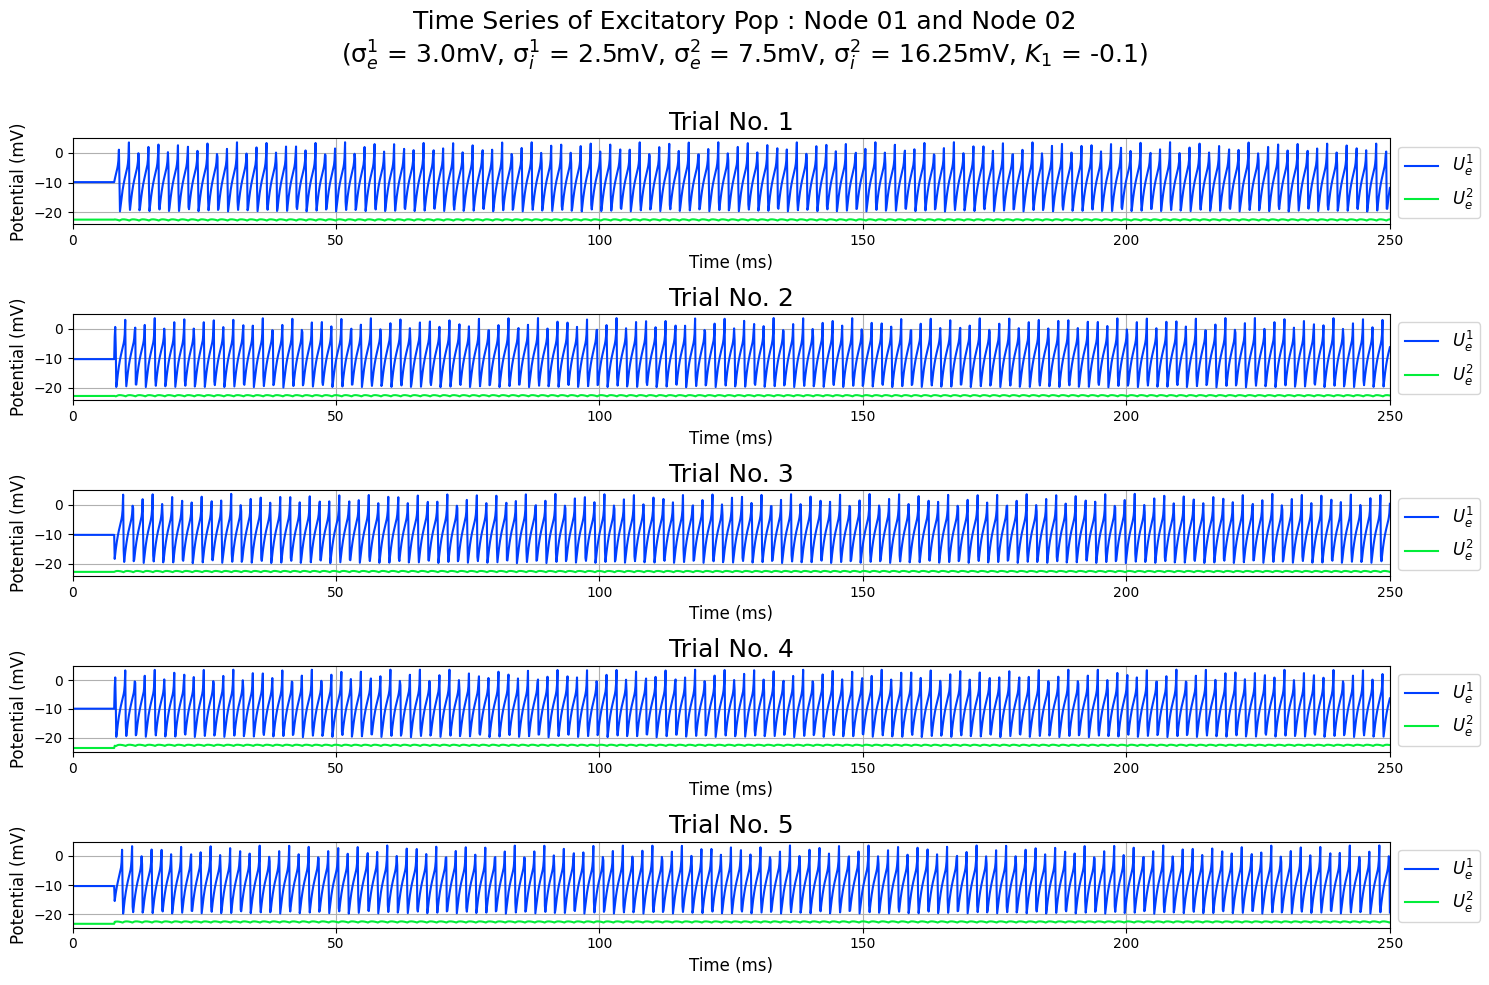

In [6]:
dt = parameters['dt'] # sampling interval (ms)

ue1_label = "\u03C3" + r"$_e^1$" + f" = {parameters['sigmaE1']}mV"
ue2_label = "\u03C3" + r"$_e^2$" + f" = {parameters['sigmaE2']}mV"
ui1_label = "\u03C3" + r"$_i^1$" + f" = {parameters['sigmaI1']}mV"
ui2_label = "\u03C3" + r"$_i^2$" + f" = {parameters['sigmaI2']}mV"
k1_label = r"$K_1$ = " + f"{parameters['K1']}"

plt.figure(figsize=(15, 10))

for k in range(xensemble.shape[0]):
    ue1 = xensemble[k, 0, :]; ue1[:80] = np.mean(ue1)
    ue2 = xensemble[k, 2, :]; ue2[:80] = np.mean(ue2)
    plt.subplot(5, 1, k + 1)
    plt.plot(time_, ue1, label = r'$U_e^1$')
    plt.plot(time_, ue2, label = r'$U_e^2$')
    plt.ylabel('Potential (mV)', fontsize=12); plt.xlabel('Time (ms)', fontsize=12)
    plt.xlim([time_[0], time_[-1]]); plt.grid()
    plt.legend(bbox_to_anchor=(1.0, 1.0), fontsize=12)
    plt.title(f"Trial No. {k + 1}", fontsize=18)

plt.suptitle(f'Time Series of Excitatory Pop : Node 01 and Node 02\n({ue1_label}, {ui1_label}, {ue2_label}, {ui2_label}, {k1_label})\n', fontsize=18)
plt.tight_layout()  

### Discrete Fourier Transform

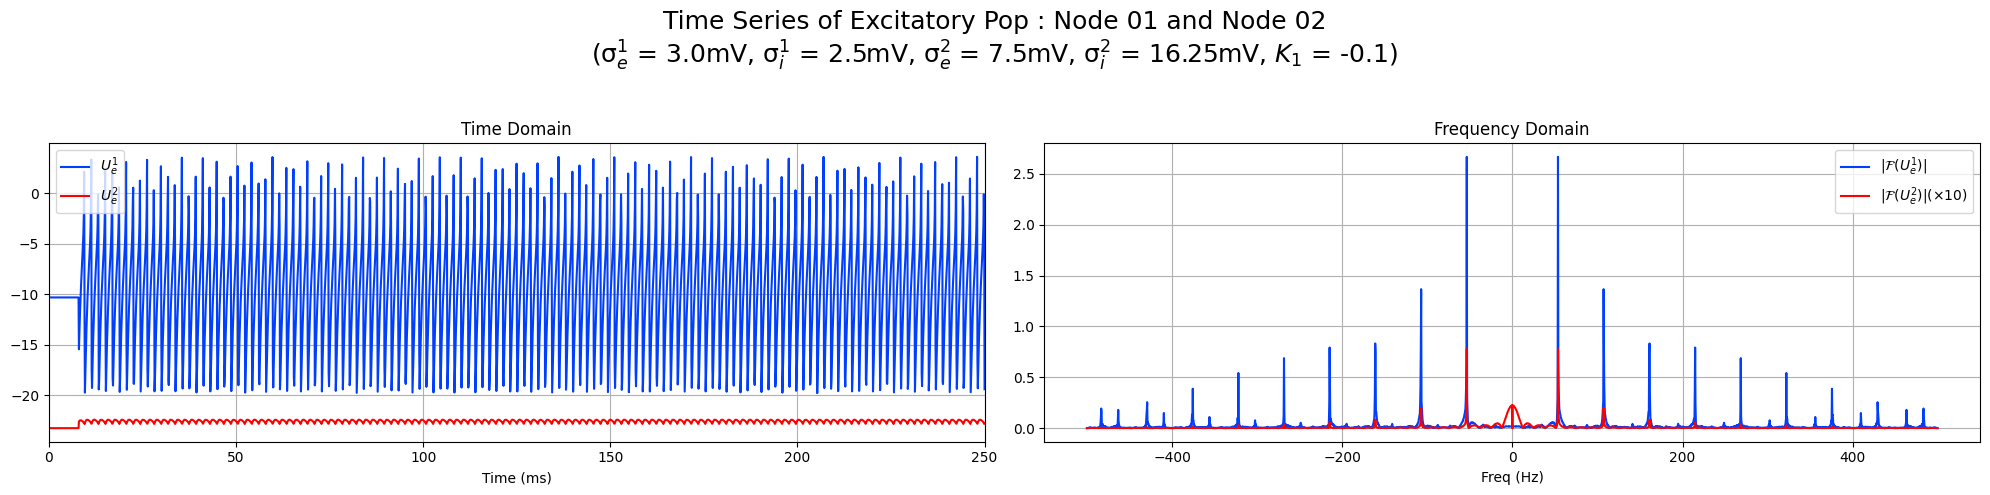

In [7]:
freq_ = np.arange(-len(time_) / 2, len(time_) / 2) * 1000 / len(time_)
fourier_ue1 = np.fft.fftshift(np.fft.fft(ue1 - np.mean(ue1)))
fourier_ue1 /= len(time_)

fourier_ue2 = np.fft.fftshift(np.fft.fft(ue2 - np.mean(ue2)))
fourier_ue2 /= len(time_)

plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plt.plot(time_, ue1, label = r'$U_e^1$'); plt.plot(time_, ue2, 'r',  label = r'$U_e^2$')
plt.xlim([time_[0], time_[-1]]); plt.xlabel('Time (ms)')
plt.legend(); plt.grid()
plt.title('Time Domain')

plt.subplot(1, 2, 2)
plt.plot(freq_, abs(fourier_ue1), label = r'$\left|\mathcal{F}(U_e^1)\right|$'); plt.plot(freq_, abs(fourier_ue2) * 10, 'r', label = r'$\left|\mathcal{F}(U_e^2)\right| (\times 10)$')
plt.xlabel('Freq (Hz)')
plt.legend(); plt.grid()
plt.title('Frequency Domain')

plt.suptitle(f'Time Series of Excitatory Pop : Node 01 and Node 02\n({ue1_label}, {ui1_label}, {ue2_label}, {ui2_label}, {k1_label})\n', fontsize=18)
plt.tight_layout()  

### STFT

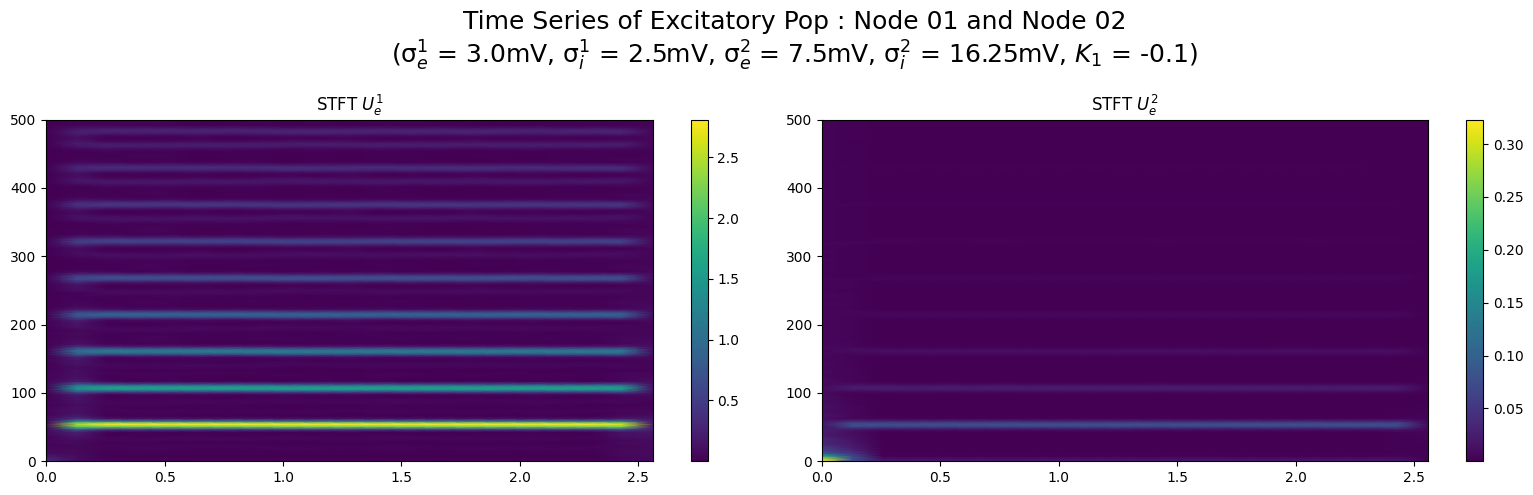

In [8]:
window_size = 256
noverlap = window_size // 2

f_ue1, t_ue1, stft_ue1 = signal.stft(ue1 - np.mean(ue1), fs = 1000,  window = 'blackman', nperseg = window_size, noverlap = noverlap)
f_ue2, t_ue2, stft_ue2 = signal.stft(ue2 - np.mean(ue2), fs = 1000,  window = 'blackman', nperseg = window_size, noverlap = noverlap)

plt.figure(figsize=(16,5))
plt.subplot(1, 2, 1)
plt.pcolormesh(t_ue1, f_ue1, abs(stft_ue1), shading='gouraud')
plt.colorbar()
plt.title(r"STFT $U_e^1$")

plt.subplot(1, 2, 2)
plt.pcolormesh(t_ue2, f_ue2, abs(stft_ue2), shading='gouraud')
plt.colorbar()
plt.title(r"STFT $U_e^2$")

plt.suptitle(f'Time Series of Excitatory Pop : Node 01 and Node 02\n({ue1_label}, {ui1_label}, {ue2_label}, {ui2_label}, {k1_label})', fontsize=18)
plt.tight_layout() 

### Wavelet Analysis

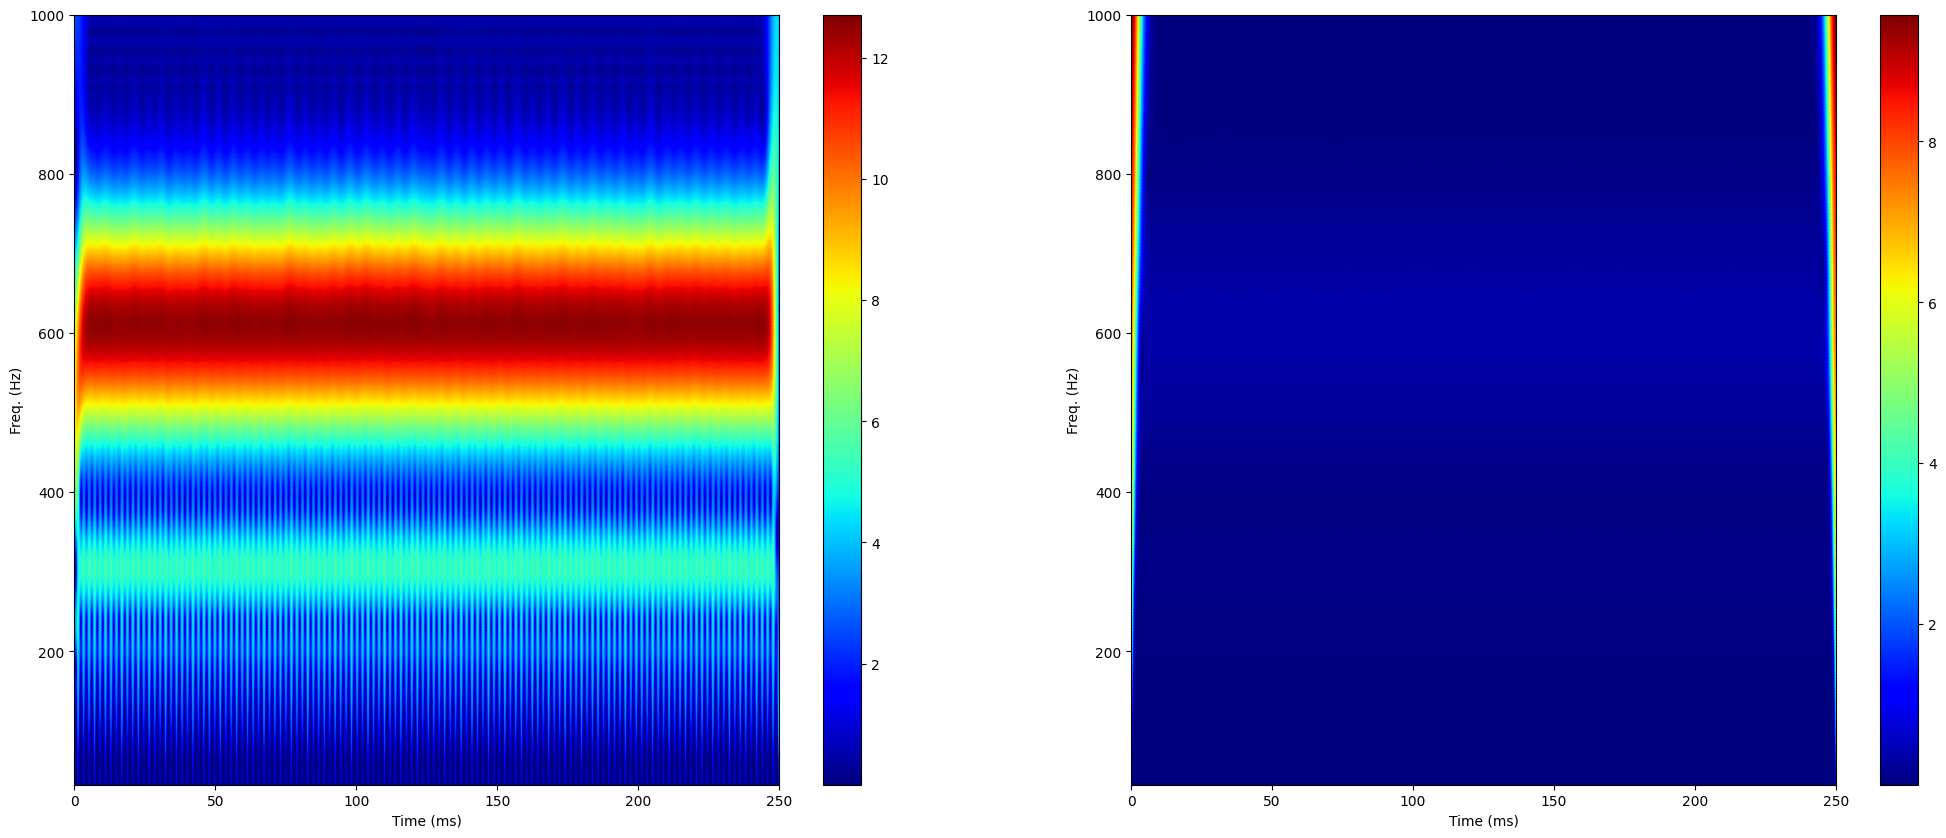

In [9]:
wavelet = 'cmor1.5-1.0'     # complex morlet with B = 1.5Hz and fc = 1.0 Hz

scales_a = np.arange(1, 31, 0.01)

ue1_cwt, freqs = pywt.cwt(ue1[100:], scales_a, wavelet, sampling_period = 1 / 1000)
ue1_cwt_flip = np.flipud(ue1_cwt)

ue2_cwt, _ = pywt.cwt(ue2[100:], scales_a, wavelet, sampling_period = 1 / 1000)
ue2_cwt_flip = np.flipud(ue2_cwt)

plt.figure(figsize=(25, 10))
plt.subplot(1, 2, 1)
plt.imshow(abs(ue1_cwt_flip), extent=[time_[0], time_[-1], freqs[-1], freqs[0]], cmap='jet', aspect='auto')
plt.ylabel('Freq. (Hz)'); plt.xlabel('Time (ms)')
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(abs(ue2_cwt_flip), extent=[time_[0], time_[-1], freqs[-1], freqs[0]], cmap='jet', aspect='auto')
plt.ylabel('Freq. (Hz)'); plt.xlabel('Time (ms)')
plt.colorbar()

plt.show()

In [10]:
parameters['K1'] = -0.1
parameters['i_e1'] = -0.25 + 0.2 
parameters['sigmaE1'] = 3.0
parameters['sigmaI2'] = 2.5

xensemble = np.zeros((5, 4, len(time_)))

for k, y0 in enumerate(zip(x0_, x1_, x2_, x3_)):
    tic = time.time()
    xSolve = solve_ivp(lambda t, y: DualNodeModel(y, t, **parameters), [0, time_[-1]], y0, method='BDF', t_eval=time_)
    x0Solve, x1Solve, x2Solve, x3Solve = xSolve['y']
    toc = time.time()
    print(f'Evaluating with random initialization No. {k + 1} --> Execution time: {toc - tic :.3f}s')

    xensemble[k, 0, :] = x0Solve
    xensemble[k, 1, :] = x1Solve
    xensemble[k, 2, :] = x2Solve
    xensemble[k, 3, :] = x3Solve

Evaluating with random initialization No. 1 --> Execution time: 11.921s


C:\Users\kgaya\AppData\Local\Temp\ipykernel_23216\4175143238.py:3: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-beta * gamma * (x - theta)))


Evaluating with random initialization No. 2 --> Execution time: 12.064s
Evaluating with random initialization No. 3 --> Execution time: 11.992s
Evaluating with random initialization No. 4 --> Execution time: 13.097s
Evaluating with random initialization No. 5 --> Execution time: 12.277s


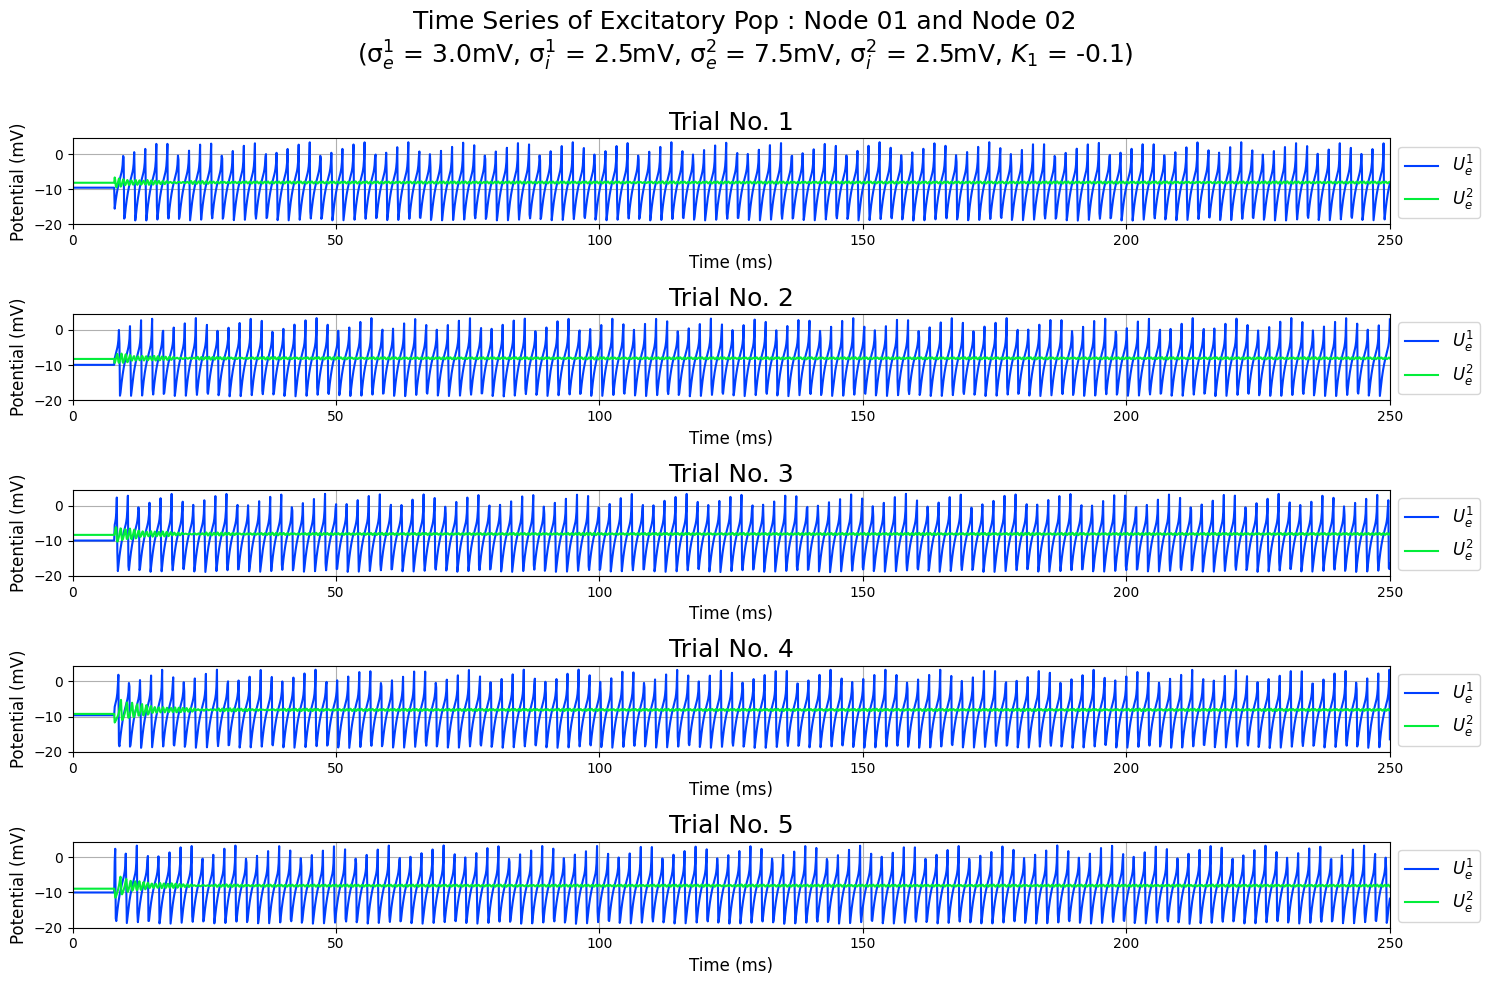

In [11]:
dt = parameters['dt'] # sampling interval (ms)

ue1_label = "\u03C3" + r"$_e^1$" + f" = {parameters['sigmaE1']}mV"
ue2_label = "\u03C3" + r"$_e^2$" + f" = {parameters['sigmaE2']}mV"
ui1_label = "\u03C3" + r"$_i^1$" + f" = {parameters['sigmaI1']}mV"
ui2_label = "\u03C3" + r"$_i^2$" + f" = {parameters['sigmaI2']}mV"
k1_label = r"$K_1$ = " + f"{parameters['K1']}"

plt.figure(figsize=(15, 10))

for k in range(xensemble.shape[0]):
    ue1 = xensemble[k, 0, :]; ue1[:80] = np.mean(ue1)
    ue2 = xensemble[k, 2, :]; ue2[:80] = np.mean(ue2)
    plt.subplot(5, 1, k + 1)
    plt.plot(time_, ue1, label = r'$U_e^1$')
    plt.plot(time_, ue2, label = r'$U_e^2$')
    plt.ylabel('Potential (mV)', fontsize=12); plt.xlabel('Time (ms)', fontsize=12)
    plt.xlim([time_[0], time_[-1]]); plt.grid()
    plt.legend(bbox_to_anchor=(1.0, 1.0), fontsize=12)
    plt.title(f"Trial No. {k + 1}", fontsize=18)

plt.suptitle(f'Time Series of Excitatory Pop : Node 01 and Node 02\n({ue1_label}, {ui1_label}, {ue2_label}, {ui2_label}, {k1_label})\n', fontsize=18)
plt.tight_layout()  

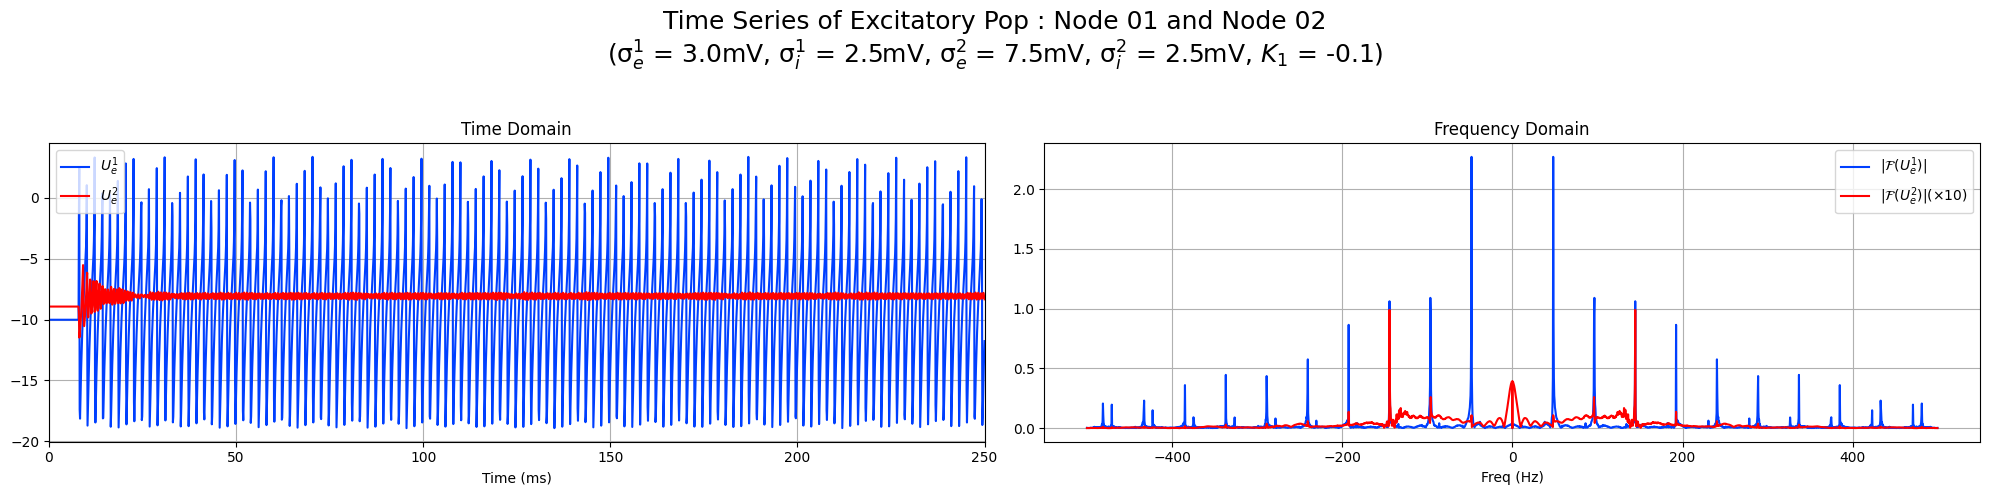

In [12]:
freq_ = np.arange(-len(time_) / 2, len(time_) / 2) * 1000 / len(time_)
fourier_ue1 = np.fft.fftshift(np.fft.fft(ue1 - np.mean(ue1)))
fourier_ue1 /= len(time_)

fourier_ue2 = np.fft.fftshift(np.fft.fft(ue2 - np.mean(ue2)))
fourier_ue2 /= len(time_)

plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plt.plot(time_, ue1, label = r'$U_e^1$'); plt.plot(time_, ue2, 'r',  label = r'$U_e^2$')
plt.xlim([time_[0], time_[-1]]); plt.xlabel('Time (ms)')
plt.legend(); plt.grid()
plt.title('Time Domain')

plt.subplot(1, 2, 2)
plt.plot(freq_, abs(fourier_ue1), label = r'$\left|\mathcal{F}(U_e^1)\right|$'); plt.plot(freq_, abs(fourier_ue2) * 10, 'r', label = r'$\left|\mathcal{F}(U_e^2)\right| (\times 10)$')
plt.xlabel('Freq (Hz)')
plt.legend(); plt.grid()
plt.title('Frequency Domain')

plt.suptitle(f'Time Series of Excitatory Pop : Node 01 and Node 02\n({ue1_label}, {ui1_label}, {ue2_label}, {ui2_label}, {k1_label})\n', fontsize=18)
plt.tight_layout()  

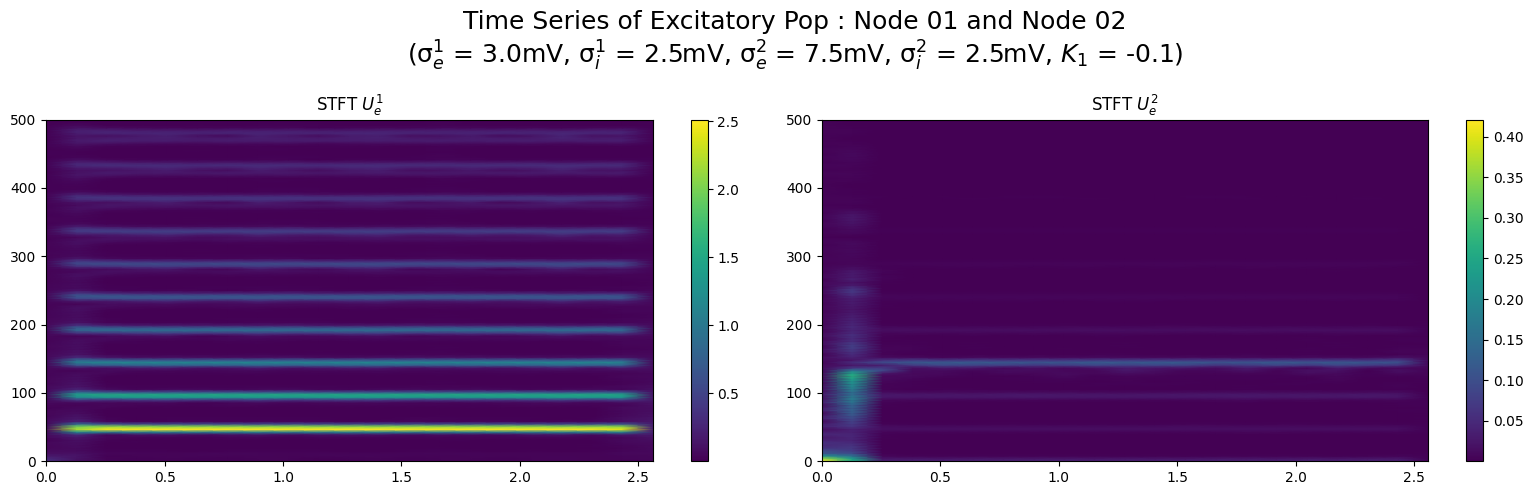

In [13]:
window_size = 256
noverlap = window_size // 2

f_ue1, t_ue1, stft_ue1 = signal.stft(ue1 - np.mean(ue1), fs = 1000,  window = 'blackman', nperseg = window_size, noverlap = noverlap)
f_ue2, t_ue2, stft_ue2 = signal.stft(ue2 - np.mean(ue2), fs = 1000,  window = 'blackman', nperseg = window_size, noverlap = noverlap)

plt.figure(figsize=(16,5))
plt.subplot(1, 2, 1)
plt.pcolormesh(t_ue1, f_ue1, abs(stft_ue1), shading='gouraud')
plt.colorbar()
plt.title(r"STFT $U_e^1$")

plt.subplot(1, 2, 2)
plt.pcolormesh(t_ue2, f_ue2, abs(stft_ue2), shading='gouraud')
plt.colorbar()
plt.title(r"STFT $U_e^2$")

plt.suptitle(f'Time Series of Excitatory Pop : Node 01 and Node 02\n({ue1_label}, {ui1_label}, {ue2_label}, {ui2_label}, {k1_label})', fontsize=18)
plt.tight_layout() 

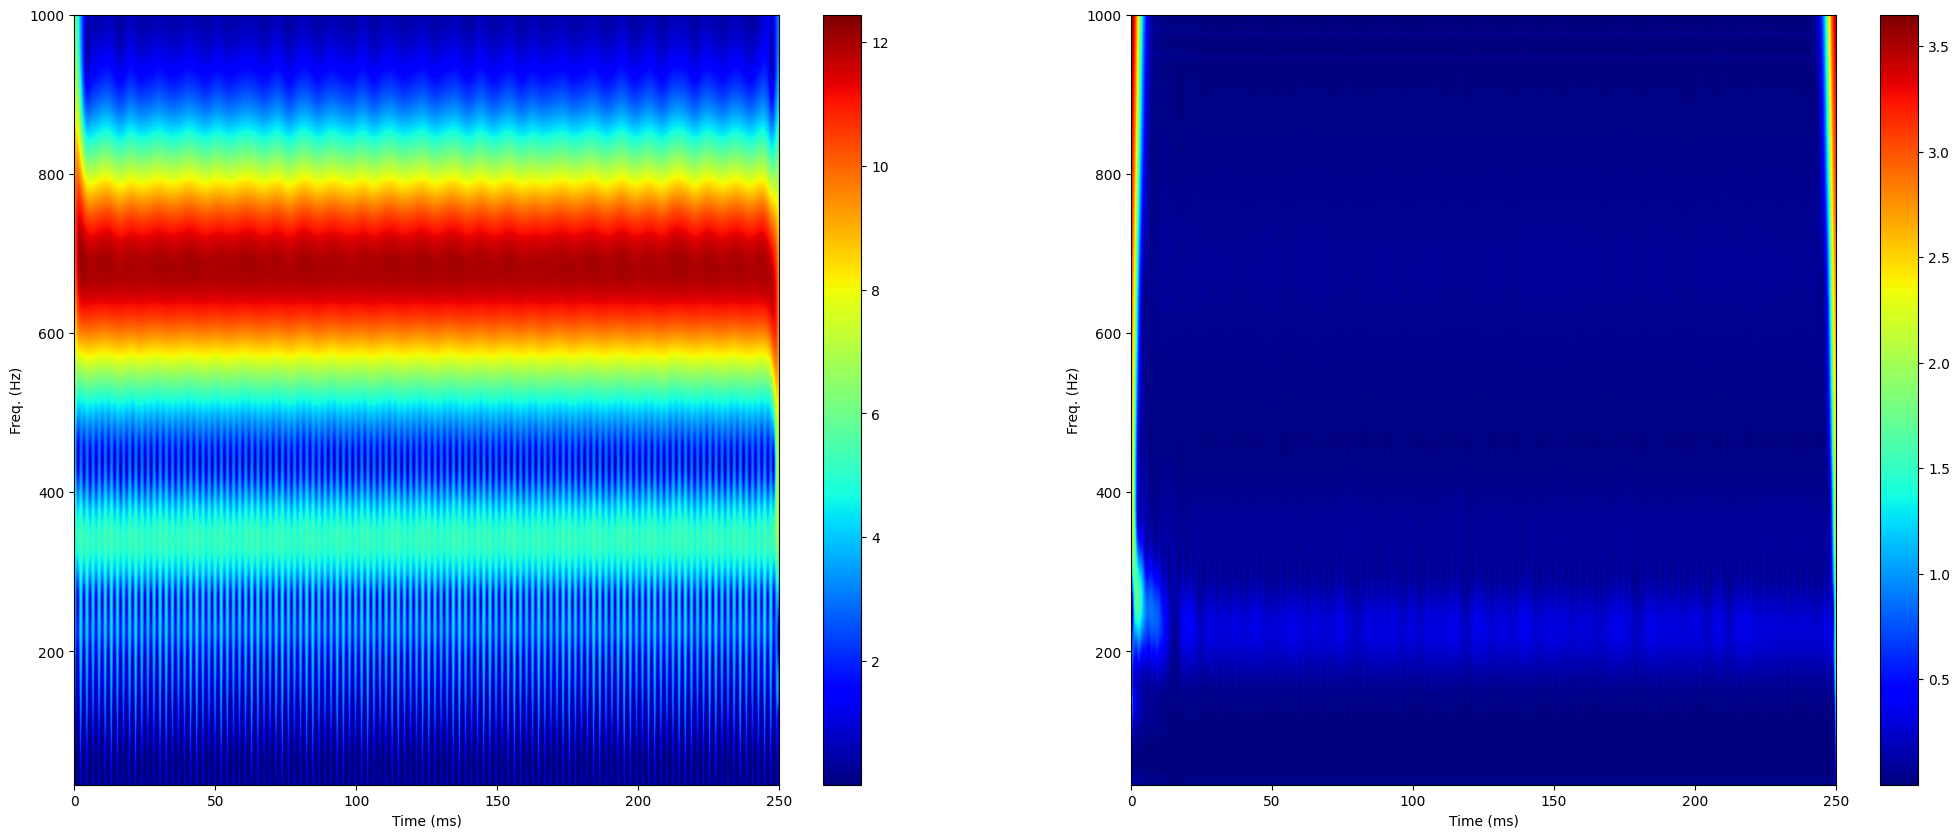

In [14]:
wavelet = 'cmor1.5-1.0'     # complex morlet with B = 1.5Hz and fc = 1.0 Hz

scales_a = np.arange(1, 31, 0.01)

ue1_cwt, freqs = pywt.cwt(ue1[100:], scales_a, wavelet, sampling_period = 1 / 1000)
ue1_cwt_flip = np.flipud(ue1_cwt)

ue2_cwt, _ = pywt.cwt(ue2[100:], scales_a, wavelet, sampling_period = 1 / 1000)
ue2_cwt_flip = np.flipud(ue2_cwt)

plt.figure(figsize=(25, 10))
plt.subplot(1, 2, 1)
plt.imshow(abs(ue1_cwt_flip), extent=[time_[0], time_[-1], freqs[-1], freqs[0]], cmap='jet', aspect='auto')
plt.ylabel('Freq. (Hz)'); plt.xlabel('Time (ms)')
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(abs(ue2_cwt_flip), extent=[time_[0], time_[-1], freqs[-1], freqs[0]], cmap='jet', aspect='auto')
plt.ylabel('Freq. (Hz)'); plt.xlabel('Time (ms)')
plt.colorbar()

plt.show()

In [27]:
parameters['K1'] = -0.1
parameters['i_e1'] = -0.25 + 0.2 
parameters['sigmaE1'] = 3.0
parameters['sigmaI2'] = 2.5
parameters['sigmaE2'] = 3.0

xensemble = np.zeros((5, 4, len(time_)))

for k, y0 in enumerate(zip(x0_, x1_, x2_, x3_)):
    tic = time.time()
    xSolve = solve_ivp(lambda t, y: DualNodeModel(y, t, **parameters), [0, time_[-1]], y0, method='BDF', t_eval=time_)
    x0Solve, x1Solve, x2Solve, x3Solve = xSolve['y']
    toc = time.time()
    print(f'Evaluating with random initialization No. {k + 1} --> Execution time: {toc - tic :.3f}s')

    xensemble[k, 0, :] = x0Solve
    xensemble[k, 1, :] = x1Solve
    xensemble[k, 2, :] = x2Solve
    xensemble[k, 3, :] = x3Solve

Evaluating with random initialization No. 1 --> Execution time: 12.904s


C:\Users\kgaya\AppData\Local\Temp\ipykernel_23216\4175143238.py:3: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-beta * gamma * (x - theta)))


Evaluating with random initialization No. 2 --> Execution time: 11.793s
Evaluating with random initialization No. 3 --> Execution time: 11.799s
Evaluating with random initialization No. 4 --> Execution time: 11.707s
Evaluating with random initialization No. 5 --> Execution time: 11.684s


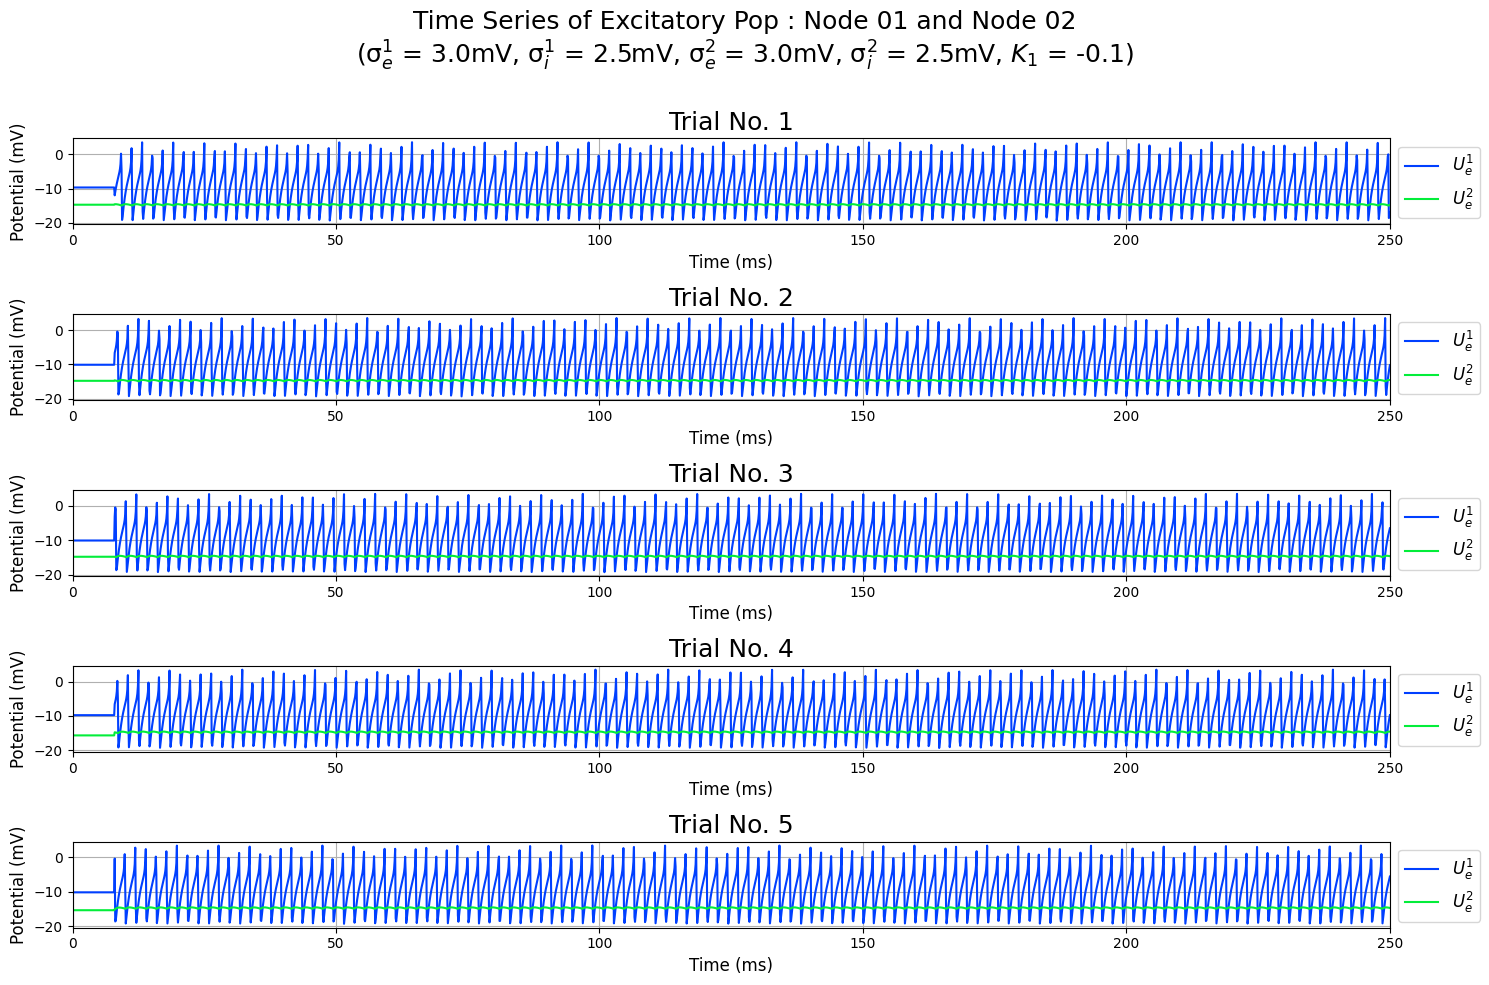

In [28]:
dt = parameters['dt'] # sampling interval (ms)

ue1_label = "\u03C3" + r"$_e^1$" + f" = {parameters['sigmaE1']}mV"
ue2_label = "\u03C3" + r"$_e^2$" + f" = {parameters['sigmaE2']}mV"
ui1_label = "\u03C3" + r"$_i^1$" + f" = {parameters['sigmaI1']}mV"
ui2_label = "\u03C3" + r"$_i^2$" + f" = {parameters['sigmaI2']}mV"
k1_label = r"$K_1$ = " + f"{parameters['K1']}"

plt.figure(figsize=(15, 10))

for k in range(xensemble.shape[0]):
    ue1 = xensemble[k, 0, :]; ue1[:80] = np.mean(ue1)
    ue2 = xensemble[k, 2, :]; ue2[:80] = np.mean(ue2)
    plt.subplot(5, 1, k + 1)
    plt.plot(time_, ue1, label = r'$U_e^1$')
    plt.plot(time_, ue2, label = r'$U_e^2$')
    plt.ylabel('Potential (mV)', fontsize=12); plt.xlabel('Time (ms)', fontsize=12)
    plt.xlim([time_[0], time_[-1]]); plt.grid()
    plt.legend(bbox_to_anchor=(1.0, 1.0), fontsize=12)
    plt.title(f"Trial No. {k + 1}", fontsize=18)

plt.suptitle(f'Time Series of Excitatory Pop : Node 01 and Node 02\n({ue1_label}, {ui1_label}, {ue2_label}, {ui2_label}, {k1_label})\n', fontsize=18)
plt.tight_layout()  

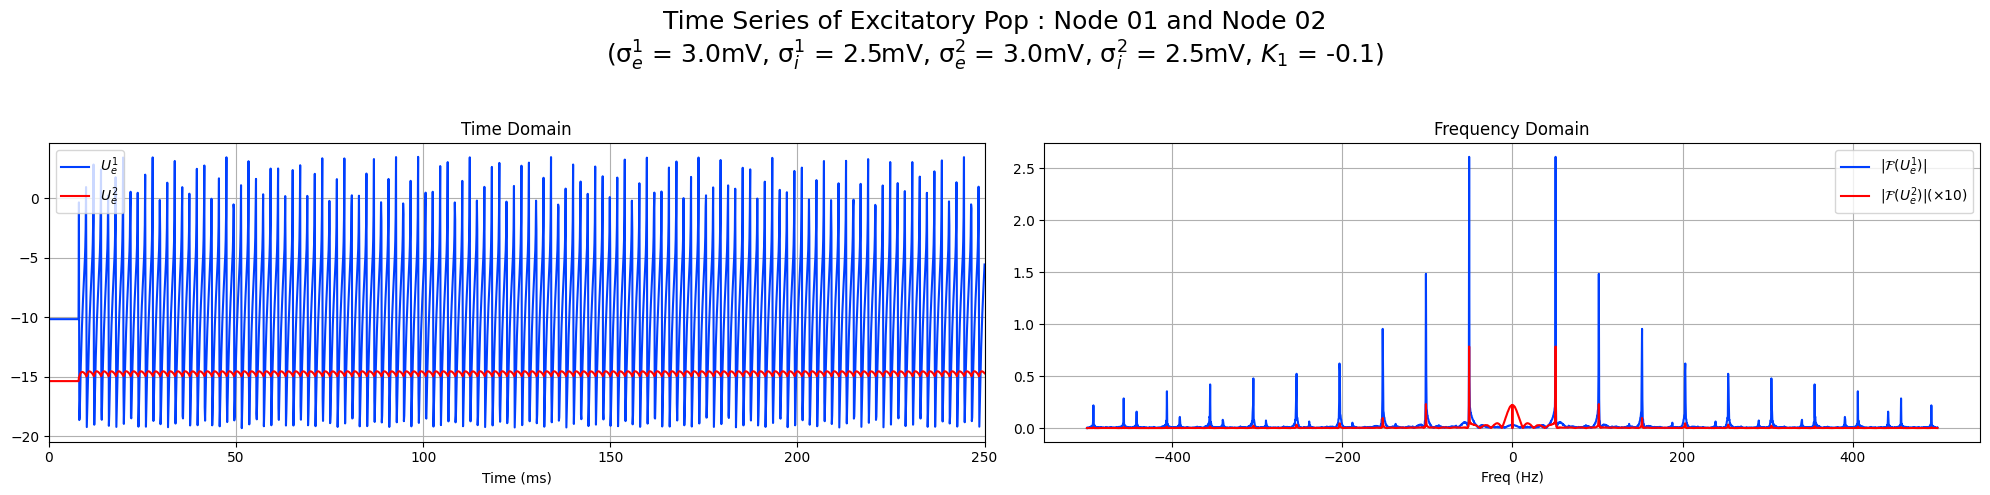

In [32]:
freq_ = np.arange(-len(time_) / 2, len(time_) / 2) * 1000 / len(time_)
fourier_ue1 = np.fft.fftshift(np.fft.fft(ue1 - np.mean(ue1)))
fourier_ue1 /= len(time_)

fourier_ue2 = np.fft.fftshift(np.fft.fft(ue2 - np.mean(ue2)))
fourier_ue2 /= len(time_)

plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plt.plot(time_, ue1, label = r'$U_e^1$'); plt.plot(time_, ue2, 'r',  label = r'$U_e^2$')
plt.xlim([time_[0], time_[-1]]); plt.xlabel('Time (ms)')
plt.legend(); plt.grid()
plt.title('Time Domain')

plt.subplot(1, 2, 2)
plt.plot(freq_, abs(fourier_ue1), label = r'$\left|\mathcal{F}(U_e^1)\right|$'); plt.plot(freq_, abs(fourier_ue2) * 10, 'r', label = r'$\left|\mathcal{F}(U_e^2)\right| (\times 10)$')
plt.xlabel('Freq (Hz)')
plt.legend(); plt.grid()
plt.title('Frequency Domain')

plt.suptitle(f'Time Series of Excitatory Pop : Node 01 and Node 02\n({ue1_label}, {ui1_label}, {ue2_label}, {ui2_label}, {k1_label})\n', fontsize=18)
plt.tight_layout()  

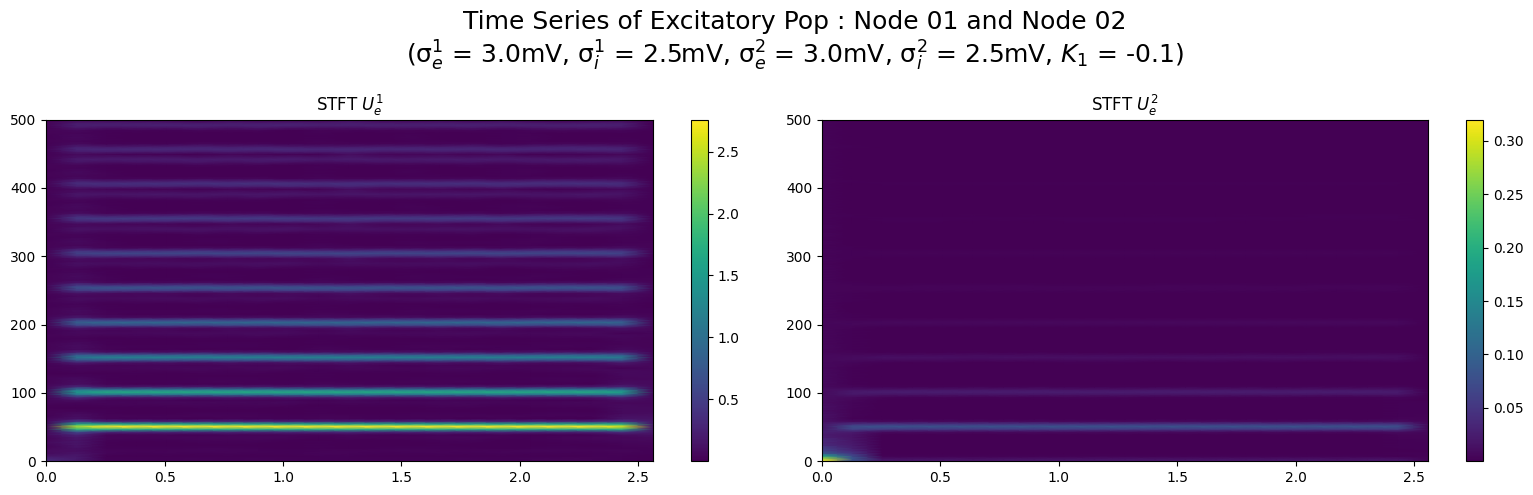

In [30]:
window_size = 256
noverlap = window_size // 2

f_ue1, t_ue1, stft_ue1 = signal.stft(ue1 - np.mean(ue1), fs = 1000,  window = 'blackman', nperseg = window_size, noverlap = noverlap)
f_ue2, t_ue2, stft_ue2 = signal.stft(ue2 - np.mean(ue2), fs = 1000,  window = 'blackman', nperseg = window_size, noverlap = noverlap)

plt.figure(figsize=(16,5))
plt.subplot(1, 2, 1)
plt.pcolormesh(t_ue1, f_ue1, abs(stft_ue1), shading='gouraud')
plt.colorbar()
plt.title(r"STFT $U_e^1$")

plt.subplot(1, 2, 2)
plt.pcolormesh(t_ue2, f_ue2, abs(stft_ue2), shading='gouraud')
plt.colorbar()
plt.title(r"STFT $U_e^2$")

plt.suptitle(f'Time Series of Excitatory Pop : Node 01 and Node 02\n({ue1_label}, {ui1_label}, {ue2_label}, {ui2_label}, {k1_label})', fontsize=18)
plt.tight_layout() 

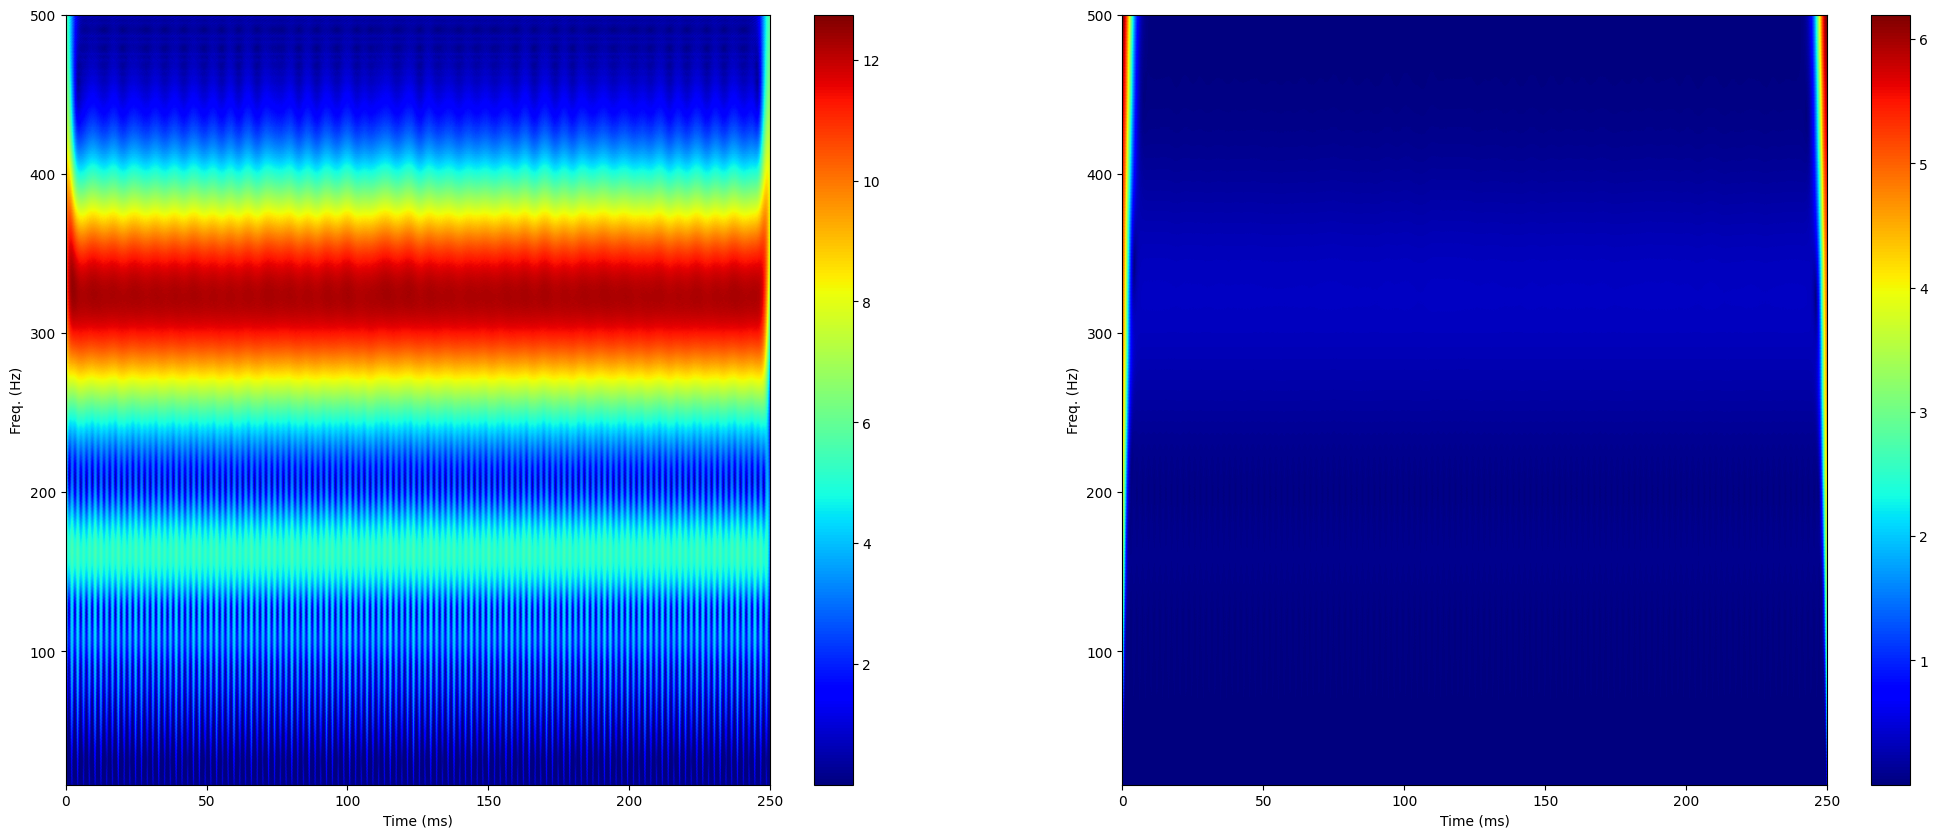

In [31]:
wavelet = 'cmor1.5-1.0'     # complex morlet with B = 1.5Hz and fc = 1.0 Hz

scales_a = np.arange(1, 31, 0.01)

ue1_cwt, freqs = pywt.cwt(ue1[100:], scales_a, wavelet, sampling_period = 2 / 1000)
ue1_cwt_flip = np.flipud(ue1_cwt)

ue2_cwt, _ = pywt.cwt(ue2[100:], scales_a, wavelet, sampling_period = 2 / 1000)
ue2_cwt_flip = np.flipud(ue2_cwt)

plt.figure(figsize=(25, 10))
plt.subplot(1, 2, 1)
plt.imshow(abs(ue1_cwt_flip), extent=[time_[0], time_[-1], freqs[-1], freqs[0]], cmap='jet', aspect='auto')
plt.ylabel('Freq. (Hz)'); plt.xlabel('Time (ms)')
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(abs(ue2_cwt_flip), extent=[time_[0], time_[-1], freqs[-1], freqs[0]], cmap='jet', aspect='auto')
plt.ylabel('Freq. (Hz)'); plt.xlabel('Time (ms)')
plt.colorbar()

plt.show()

In [24]:
parameters['K1'] = 0.0
parameters['i_e1'] = -0.25 + 0.5 
parameters['sigmaE1'] = 3.0
parameters['sigmaI2'] = 2.5
parameters['sigmaE2'] = 3.0

xensemble = np.zeros((5, 4, len(time_)))

for k, y0 in enumerate(zip(x0_, x1_, x2_, x3_)):
    tic = time.time()
    xSolve = solve_ivp(lambda t, y: DualNodeModel(y, t, **parameters), [0, time_[-1]], y0, method='BDF', t_eval=time_)
    x0Solve, x1Solve, x2Solve, x3Solve = xSolve['y']
    toc = time.time()
    print(f'Evaluating with random initialization No. {k + 1} --> Execution time: {toc - tic :.3f}s')

    xensemble[k, 0, :] = x0Solve
    xensemble[k, 1, :] = x1Solve
    xensemble[k, 2, :] = x2Solve
    xensemble[k, 3, :] = x3Solve

Evaluating with random initialization No. 1 --> Execution time: 21.613s


C:\Users\kgaya\AppData\Local\Temp\ipykernel_23216\4175143238.py:3: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-beta * gamma * (x - theta)))


Evaluating with random initialization No. 2 --> Execution time: 20.631s
Evaluating with random initialization No. 3 --> Execution time: 20.003s
Evaluating with random initialization No. 4 --> Execution time: 21.391s
Evaluating with random initialization No. 5 --> Execution time: 20.260s


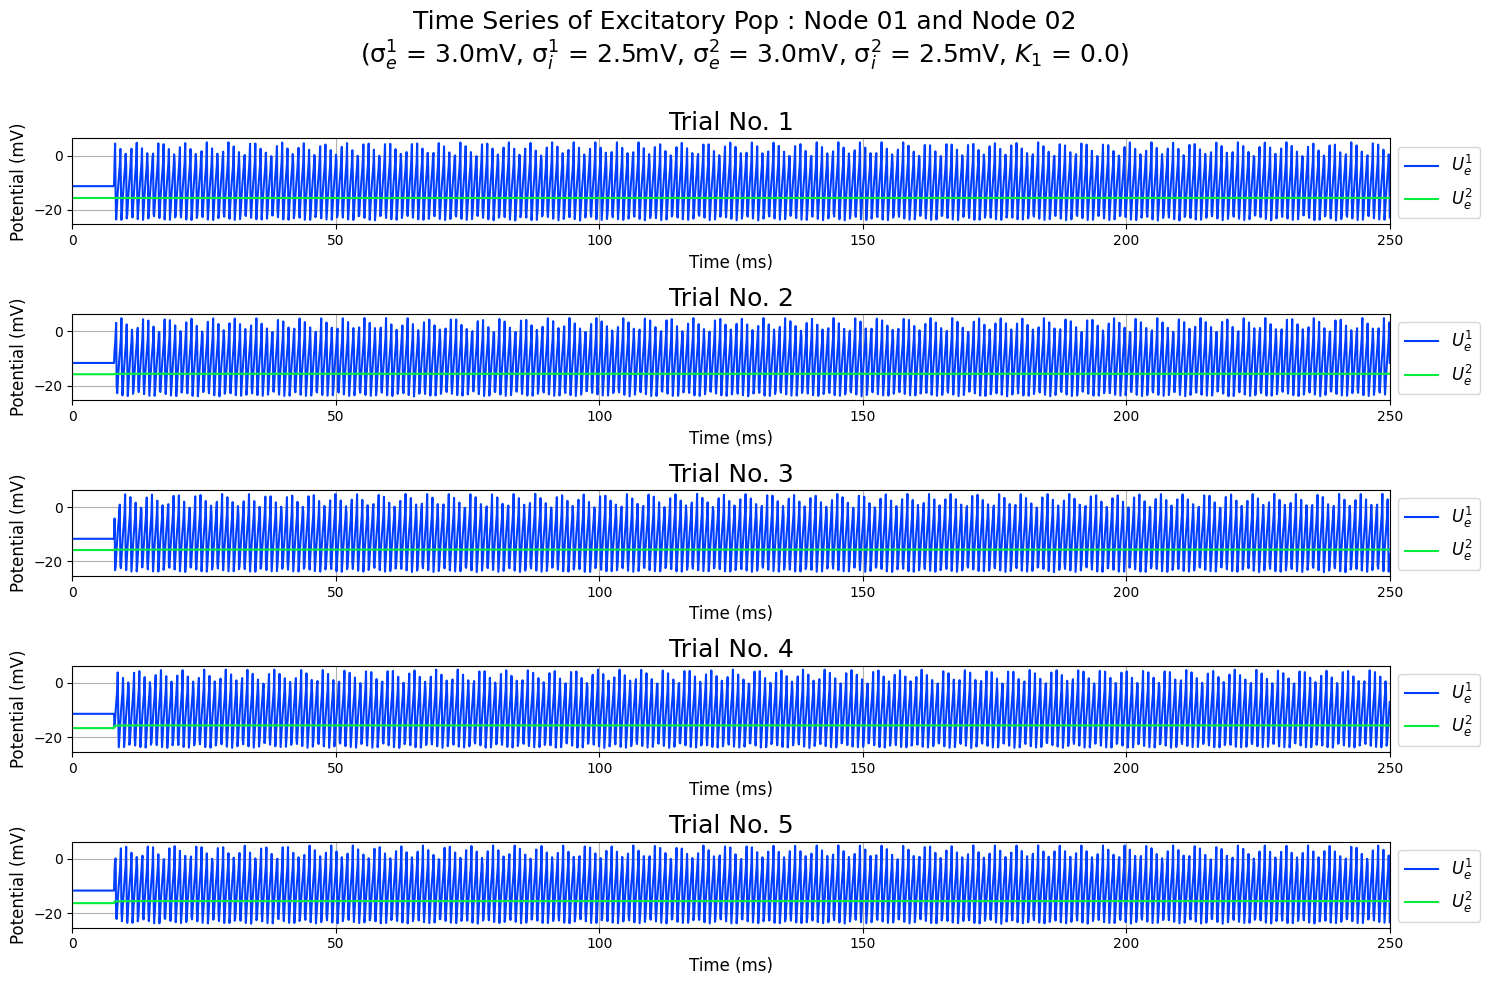

In [25]:
dt = parameters['dt'] # sampling interval (ms)

ue1_label = "\u03C3" + r"$_e^1$" + f" = {parameters['sigmaE1']}mV"
ue2_label = "\u03C3" + r"$_e^2$" + f" = {parameters['sigmaE2']}mV"
ui1_label = "\u03C3" + r"$_i^1$" + f" = {parameters['sigmaI1']}mV"
ui2_label = "\u03C3" + r"$_i^2$" + f" = {parameters['sigmaI2']}mV"
k1_label = r"$K_1$ = " + f"{parameters['K1']}"

plt.figure(figsize=(15, 10))

for k in range(xensemble.shape[0]):
    ue1 = xensemble[k, 0, :]; ue1[:80] = np.mean(ue1)
    ue2 = xensemble[k, 2, :]; ue2[:80] = np.mean(ue2)
    plt.subplot(5, 1, k + 1)
    plt.plot(time_, ue1, label = r'$U_e^1$')
    plt.plot(time_, ue2, label = r'$U_e^2$')
    plt.ylabel('Potential (mV)', fontsize=12); plt.xlabel('Time (ms)', fontsize=12)
    plt.xlim([time_[0], time_[-1]]); plt.grid()
    plt.legend(bbox_to_anchor=(1.0, 1.0), fontsize=12)
    plt.title(f"Trial No. {k + 1}", fontsize=18)

plt.suptitle(f'Time Series of Excitatory Pop : Node 01 and Node 02\n({ue1_label}, {ui1_label}, {ue2_label}, {ui2_label}, {k1_label})\n', fontsize=18)
plt.tight_layout()  

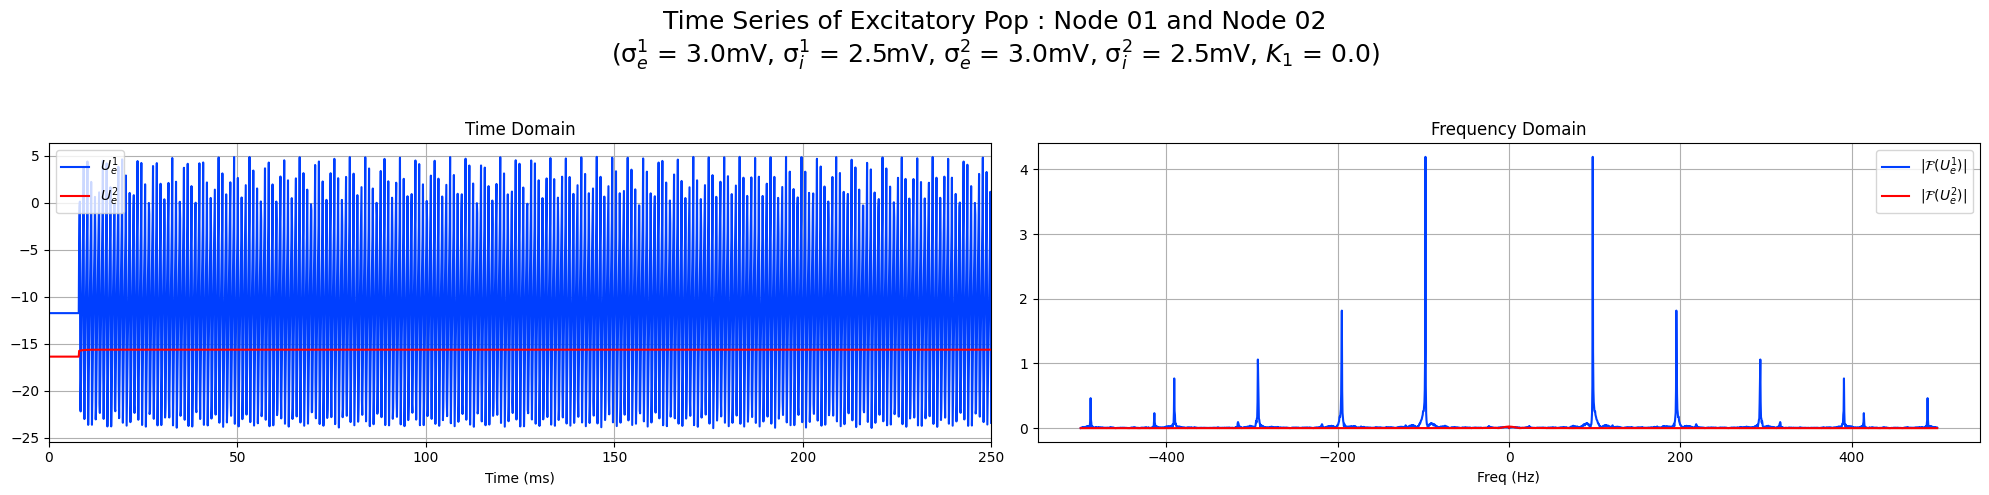

In [26]:
freq_ = np.arange(-len(time_) / 2, len(time_) / 2) * 1000 / len(time_)
fourier_ue1 = np.fft.fftshift(np.fft.fft(ue1 - np.mean(ue1)))
fourier_ue1 /= len(time_)

fourier_ue2 = np.fft.fftshift(np.fft.fft(ue2 - np.mean(ue2)))
fourier_ue2 /= len(time_)

plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plt.plot(time_, ue1, label = r'$U_e^1$'); plt.plot(time_, ue2, 'r',  label = r'$U_e^2$')
plt.xlim([time_[0], time_[-1]]); plt.xlabel('Time (ms)')
plt.legend(); plt.grid()
plt.title('Time Domain')

plt.subplot(1, 2, 2)
plt.plot(freq_, abs(fourier_ue1), label = r'$\left|\mathcal{F}(U_e^1)\right|$'); plt.plot(freq_, abs(fourier_ue2), 'r', label = r'$\left|\mathcal{F}(U_e^2)\right|$')
plt.xlabel('Freq (Hz)')
plt.legend(); plt.grid()
plt.title('Frequency Domain')

plt.suptitle(f'Time Series of Excitatory Pop : Node 01 and Node 02\n({ue1_label}, {ui1_label}, {ue2_label}, {ui2_label}, {k1_label})\n', fontsize=18)
plt.tight_layout()  